In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

In [2]:
def load_and_process_csv(file_path):
    # Charger les données CSV avec pandas
    df = pd.read_csv(file_path)
    # Convertir en numpy array pour traitement similaire
    dataN = df.to_numpy()
    return dataN

def GRlaw(Corners4, mag_ini, mag_end, newdataN, yr_min, inv1):
    x2a = Corners4[0]
    x2b = Corners4[1]
    y2a = Corners4[2]
    y2b = Corners4[3]

    min_depth = -10  # km
    ntot1 = newdataN.shape[0]

    distmag = np.zeros((mag_end - mag_ini, 2))  # (bins, 2)

    for n in range(ntot1):
        for p in range(mag_ini, mag_end):
            # indices Python : distmag[p - mag_ini, :]
            # Extraction colonnes avec indexation 0-based:
            year = newdataN[n, 0]
            lat = newdataN[n, 6]
            lon = newdataN[n, 7]
            depth = newdataN[n, 8]
            mag = newdataN[n, 9]

            # Conditions premières :
            cond1 = (year >= yr_min) and (depth > min_depth) and (mag >= p) and (mag < p + 1) \
                    and (lat >= y2a) and (lat <= y2b)

            # Case inv1==0 : longitude entre x2a et x2b
            if cond1 and (lon >= x2a) and (lon <= x2b) and (not inv1):
                distmag[p - mag_ini, 0] += 1
                distmag[p - mag_ini, 1] = p + 0.5

            # Case inv1==1 : longitude entre x2a et 180 OU -180 et x2b (méridien 180 traversé)
            if inv1 == 1 and cond1 and ((lon >= x2a and lon <= 180) or (lon >= -180 and lon <= x2b)):
                distmag[p - mag_ini, 0] += 1
                distmag[p - mag_ini, 1] = p + 0.5

    return distmag

def GRlawSMoment(corners4, mag_ini, mag_end, newdataN, yr_min, inv1=False):
    """
    Estime la densité d'énergie sismique par bin de magnitude dans une zone géographique.
    
    Parameters:
        corners4 : list or array of float
            [lon_min, lon_max, lat_min, lat_max]
        mag_ini : int
            Magnitude minimale (ex. 4)
        mag_end : int
            Magnitude maximale (ex. 9)
        newdataN : np.ndarray
            Table d’événements : colonnes = [annee, ..., lat (7), lon (8), profondeur (9), magnitude (10)]
        yr_min : int
            Année minimale à considérer
        inv1 : bool
            True si on traverse la ligne de changement de date (180°)
    
    Returns:
        distSM : np.ndarray of shape (mag_end - mag_ini, 2)
            distSM[:,0] = densité d’énergie sismique par bin
            distSM[:,1] = énergie moyenne pour chaque bin de magnitude
    """

    x2a, x2b, y2a, y2b = corners4
    min_depth = 1  # km

    n_bins = mag_end - mag_ini
    distmag = np.zeros((n_bins, 2))
    distSM = np.zeros((n_bins, 2))

    N_events = 0
    for n in range(newdataN.shape[0]):
        year = newdataN[n, 0]
        lat = newdataN[n, 6]
        lon = newdataN[n, 7]
        depth = newdataN[n, 8]
        mag = newdataN[n, 9]

        for p in range(mag_ini, mag_end):
            in_mag_bin = (mag >= p) and (mag < p + 1)
            in_area = (x2a <= lon <= x2b) and (y2a <= lat <= y2b)
            in_cross_area = ((x2a <= lon <= 180) or (-180 <= lon <= x2b)) and (y2a <= lat <= y2b)

            if year >= yr_min and depth > min_depth and in_mag_bin:
                if (not inv1 and in_area) or (inv1 and in_cross_area):
                    idx = p - mag_ini
                    distmag[idx, 0] += 1
                    distmag[idx, 1] = p + 0.5
                    N_events += 1

    # Constantes pour conversion magnitude  énergie
    cst = 1.5 * 6.07  # correspond à 10^(1.5M + cst)

    SumE = 0
    SumE2 = 0

    for p in range(mag_ini, mag_end):
        idx = p - mag_ini
        mag_bin_center = p + 0.5
        e_center = 10 ** (1.5 * mag_bin_center + cst)
        e_bin = 10 ** (1.5 * (p + 1) + cst) - 10 ** (1.5 * p + cst)

        distSM[idx, 1] = e_center
        distSM[idx, 0] = distmag[idx, 0] / e_bin if e_bin != 0 else 0

        SumE += e_center * distSM[idx, 0]
        SumE2 += distSM[idx, 0] * e_bin

    print(f"N_events: {N_events}")
    print(f"SumE: {SumE:.3e}")
    print(f"SumE2: {SumE2:.3e}")

    return distSM

def magnitude(energy):
    return (2/3) * np.log10(energy) - 6.07

def energy(magnitude):
    return 10 ** (1.5 * (magnitude + 6.07))

# Figure 1

In [3]:
Etot = 6.5297e+22  / 40 #0.37 to remove Tohoku

Mag_max = 8
Mag_min = 0
nbins= Mag_max - Mag_min+1

magnitude_x = np.linspace(Mag_min,Mag_max,nbins) + 0.5
energy_center = np.array(10 ** (1.5 * (magnitude_x + 6.07)))
energy_edges = energy(np.linspace(Mag_min, Mag_max+0.9, nbins+1))


tau = 1.67
E = energy_center
dE = np.diff(energy_edges)
Emax = energy(Mag_max)
Emin = energy(Mag_min)
k_orig = Etot / np.sum(E**(1-tau) * dE) #Constant Energy E_tot
# N_ref_tot = k_orig * ( (Emax**(1-tau)) - (Emin**(1-tau)) )/(1 - tau)
N_ref_tot = k_orig * np.sum(E**(-tau)*dE)

P_E = k_orig * energy_center ** (-tau) 
norm_P_E = P_E/N_ref_tot

magnitude_y = P_E * 1.5 * np.log(10) * E
print(magnitude_y)

mean_energy_x = np.sum(E * norm_P_E * dE)
mean_energy_y = k_orig * mean_energy_x ** (-tau)

mean_magnitude_x= magnitude(mean_energy_x) #Moyenne des energies en magnitude
yE_mag = k_orig *  mean_energy_x ** (-tau)
mean_magnitude_y = yE_mag * 1.5 * np.log(10) *  mean_energy_x

[1.49687605e+07 1.47974145e+06 1.46280299e+05 1.44605843e+04
 1.42950553e+03 1.41314212e+02 1.39696601e+01 1.38097508e+00
 1.36516719e-01]


In [4]:
#%%# Chargement des données Japan.csv
data_jap = load_and_process_csv('/home/kduplat/Documents/Data/Pscript2/Papier_Memory/RealEarthquakes/Japan.csv')

ntot1, n = data_jap.shape
total_events = ntot1

# Définition des coins pour le Japon
Corners_Japan = [123, 163, 26, 50]
x2a, x2b = Corners_Japan[0], Corners_Japan[1]
y2a, y2b = Corners_Japan[2], Corners_Japan[3]

min_depth = -10  # km
YearIni = 1983
YearEnd = 2023

# Conversion des dates en années (équivalent MATLAB)
date2 = ((YearEnd - YearIni) / (data_jap[-1,10] - data_jap[1,10])) * (data_jap[:,10] - data_jap[-1,10]) + YearEnd
# data2 = dataN[:, 9]  # MAG
# Moment sismique cumulatif Japon
SMR1_jap = np.zeros((ntot1, 2))
mag_min = 0
ymin = 1980

k = -1
for i in range(ntot1):
    if (data_jap[i,9] >= mag_min and data_jap[i,0] >= ymin and
        data_jap[i,8] > min_depth and x2a <= data_jap[i,7] <= x2b and y2a <= data_jap[i,6] <= y2b):
        k += 1
        SMR1_jap[k, 1] = data_jap[i,11] if k == 0 else SMR1_jap[k-1, 1] + data_jap[i,11]
        SMR1_jap[k, 0] = date2[i]

SMR1_jap = SMR1_jap[:k+1]

In [5]:
#%% DONNEES JAPON

#%% Loi de Gutenberg-Richter (exemple avec GRlaw)
mag_ini, mag_end = 3, 10
first_year = 2000
last_year = 2023
distMAG_jap = np.zeros((mag_end - mag_ini, 2))
distMAG_jap[:, :] = GRlaw(Corners_Japan, mag_ini, mag_end, data_jap, first_year, 0)

distMAGMom_jap = np.zeros((mag_end - mag_ini, 2))
distMAGMom_jap[:, :] = GRlawSMoment(Corners_Japan, mag_ini, mag_end, data_jap, first_year, 0)



N_events: 145334
SumE: 2.669e+04
SumE2: 1.453e+05


In [6]:
Fitx = distMAG_jap[:, 1]  # Japon
Fity = np.log10(distMAG_jap[:, 0] / (last_year - first_year))

popt, pcov = curve_fit(expfct2, Fitx[2:6], Fity[2:6], maxfev = 1000)
b_jap = popt[1]
perr = np.sqrt(np.diag(pcov))
err_b_jap = perr[1]
print("Longueur caracteristique Magnitude= ", b_jap)

fitx_mag_jap = Fitx
fity_mag_jap = 10**(expfct2(fitx_mag_jap, *popt))


# Loi GR selon le moment sismique

Fitx = np.log(distMAGMom_jap[:, 1])
Fity = np.log(distMAGMom_jap[:, 0] / (last_year - first_year))

popt, pcov = curve_fit(powerlaw2, Fitx[2:6], Fity[2:6], p0 = [0.5, 1.6], maxfev = 1000)
beta_jap = popt[1]
perr = np.sqrt(np.diag(pcov))
err_beta_jap = perr[1]

fitx_jap = distMAGMom_jap[:, 1]
fity_jap = np.exp(powerlaw2(Fitx, *popt))

print("Tau Seismic moment= ", beta_jap)

# P1 = np.polyfit(Fitx, Fity, 1)
# fitx_jap = 10 ** (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07)
# fity_jap = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])

# fitx_bis_jap = 10 ** (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07)
# fity_bis_jap = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])



Longueur caracteristique Magnitude=  -1.0108781206126438
Tau Seismic moment=  -1.6700387982885456


In [7]:
#%% DONNEES CALIFORNIE

from datetime import datetime
#%% --- Même logique pour la Californie ---

data_cal = load_and_process_csv('/home/kduplat/Documents/Data/Pscript2/Papier_Memory/RealEarthquakes/CaliforniaM01.csv')
ntot1, n = data_cal.shape
total_events = ntot1
#%%
MPI = -360
Corners_California = [238.24 + MPI, 246.85 + MPI, 30.0948, 39.5]
x2a, x2b = Corners_California[0], Corners_California[1]
y2a, y2b = Corners_California[2], Corners_California[3]

min_depth = -10
YearIni = 1980
YearEnd = 2023

date2 = ((YearEnd - YearIni) / (data_cal[-1,10] - data_cal[0,10])) * (data_cal[:,10] - data_cal[-1,10]) + YearEnd
data2 = data_cal[:,9]

#%%
magyear = np.zeros((44, 10))
numyear = np.zeros((44, 10))

for y1 in range(1980, 2024):
    y11 = datetime(y1 - 1, 12, 31, 23, 59, 59, 990000).timestamp()
    y12 = datetime(y1, 12, 31, 23, 59, 59, 990000).timestamp()
    for i in range(ntot1):
        for mag01 in range(1, 10):
            if (mag01 <= data2[i] < mag01 + 1 and
                y11 <= data_cal[i,10] < y12 and
                data_cal[i,8] > min_depth and
                x2a <= data_cal[i,7] <= x2b and
                y2a <= data_cal[i,6] <= y2b):
                magyear[y1 - 1980, mag01 - 1] += 1
                numyear[y1 - 1980, mag01 - 1] = y1

SMR1_cal = np.zeros((ntot1, 2))
mag_min = 0
ymin = 1980

k = -1
for i in range(ntot1):
    if (data_cal[i,9] >= mag_min and data_cal[i,0] >= ymin and
        data_cal[i,8] > min_depth and x2a <= data_cal[i,7] <= x2b and y2a <= data_cal[i,6] <= y2b):
        k += 1
        SMR1_cal[k, 1] = data_cal[i,11] if k == 0 else SMR1_cal[k-1, 1] + data_cal[i,11]
        SMR1_cal[k, 0] = date2[i]

SMR1_cal = SMR1_cal[:k+1]

In [8]:

#%% Loi de Gutenberg-Richter (exemple avec GRlaw)
mag_ini, mag_end = 1, 8
first_year = 1980
last_year = 2023


distMAG_cal = np.zeros((mag_end - mag_ini, 2))
distMAG_cal[:, :] = GRlaw(Corners_California, mag_ini, mag_end, data_cal, first_year, 0)

Fitx = distMAG_cal[:, 1]  # Japon
Fity = np.log10(distMAG_cal[:, 0] / (last_year - first_year))

popt, pcov = curve_fit(expfct2, Fitx[1:6], Fity[1:6], maxfev = 1000)
b_cal = popt[1]
perr = np.sqrt(np.diag(pcov))
err_b_cal = perr[1]
print("Longueur caracteristique Magnitude= ", b_cal)

fitx_mag_cal = Fitx
fity_mag_cal = 10**(expfct2(fitx_mag_cal, *popt))

#Seismic moment

distMAGMom_cal = np.zeros((mag_end - mag_ini, 2))
distMAGMom_cal[:, :] = GRlawSMoment(Corners_California, mag_ini, mag_end, data_cal, first_year, 0)

Fitx = np.log(distMAGMom_cal[:, 1])
Fity = np.log(distMAGMom_cal[:, 0] / (last_year - first_year))

# P1 = np.polyfit(Fitx, Fity, 1)

popt, pcov = curve_fit(powerlaw2, Fitx[1:6], Fity[1:6], p0 = [0.5, 1.6], maxfev = 1000)
beta_cal = popt[1]
perr = np.sqrt(np.diag(pcov))
err_beta_cal = perr[1]

print("Tau Seismic moment= ", beta_cal)

fitx_cal = distMAGMom_cal[:, 1]
fity_cal = np.exp(powerlaw2(Fitx, *popt))

# fitx_cal = 10 ** (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07)
# fity_cal = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])

# fitx_bis_cal = 10 ** (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07)
# fity_bis_cal = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])



Longueur caracteristique Magnitude=  -1.0325839081165804
N_events: 507201
SumE: 9.314e+04
SumE2: 5.072e+05
Tau Seismic moment=  -1.6817440051251018


In [9]:
####Japan
SUM = np.sum(distMAG_jap[:, 0]/43)
N_sup_m_jap = np.array([SUM - np.sum(distMAG_jap[:i, 0]/43) for i in range(len(distMAG_jap))])

mask = N_sup_m_jap!=0
Fitx = distMAG_jap[:, 1][mask]
Fity = np.log10(N_sup_m_jap[mask])

popt, pcov = curve_fit(expfct2, Fitx[2:6], Fity[2:6], maxfev = 1000)
exp_cdf_jap = popt[1]
perr = np.sqrt(np.diag(pcov))
err_cdf_jap = perr[1]
print("Longueur caracteristique CDF jap= ", exp_cdf_jap)

fitx_cdf_jap = Fitx
fity_cdf_jap = 10**(expfct2(fitx_cdf_jap, *popt))

####California

SUM = np.sum(distMAG_cal[:, 0]/43)
N_sup_m_cal = np.array([SUM - np.sum(distMAG_cal[:i, 0]/43) for i in range(len(distMAG_cal))])

mask = N_sup_m_cal!=0
Fitx = distMAG_cal[:, 1][mask]
Fity = np.log10(N_sup_m_cal[mask])

popt, pcov = curve_fit(expfct2, Fitx[2:6], Fity[2:6], maxfev = 1000)
exp_cdf_cal = popt[1]
perr = np.sqrt(np.diag(pcov))
err_cdf_cal = perr[1]
print("Longueur caracteristique CDF cal= ", exp_cdf_cal)

fitx_cdf_cal = Fitx
fity_cdf_cal = 10**(expfct2(fitx_cdf_cal, *popt))

Longueur caracteristique CDF jap=  -0.9908991278951734
Longueur caracteristique CDF cal=  -1.0121161406300394


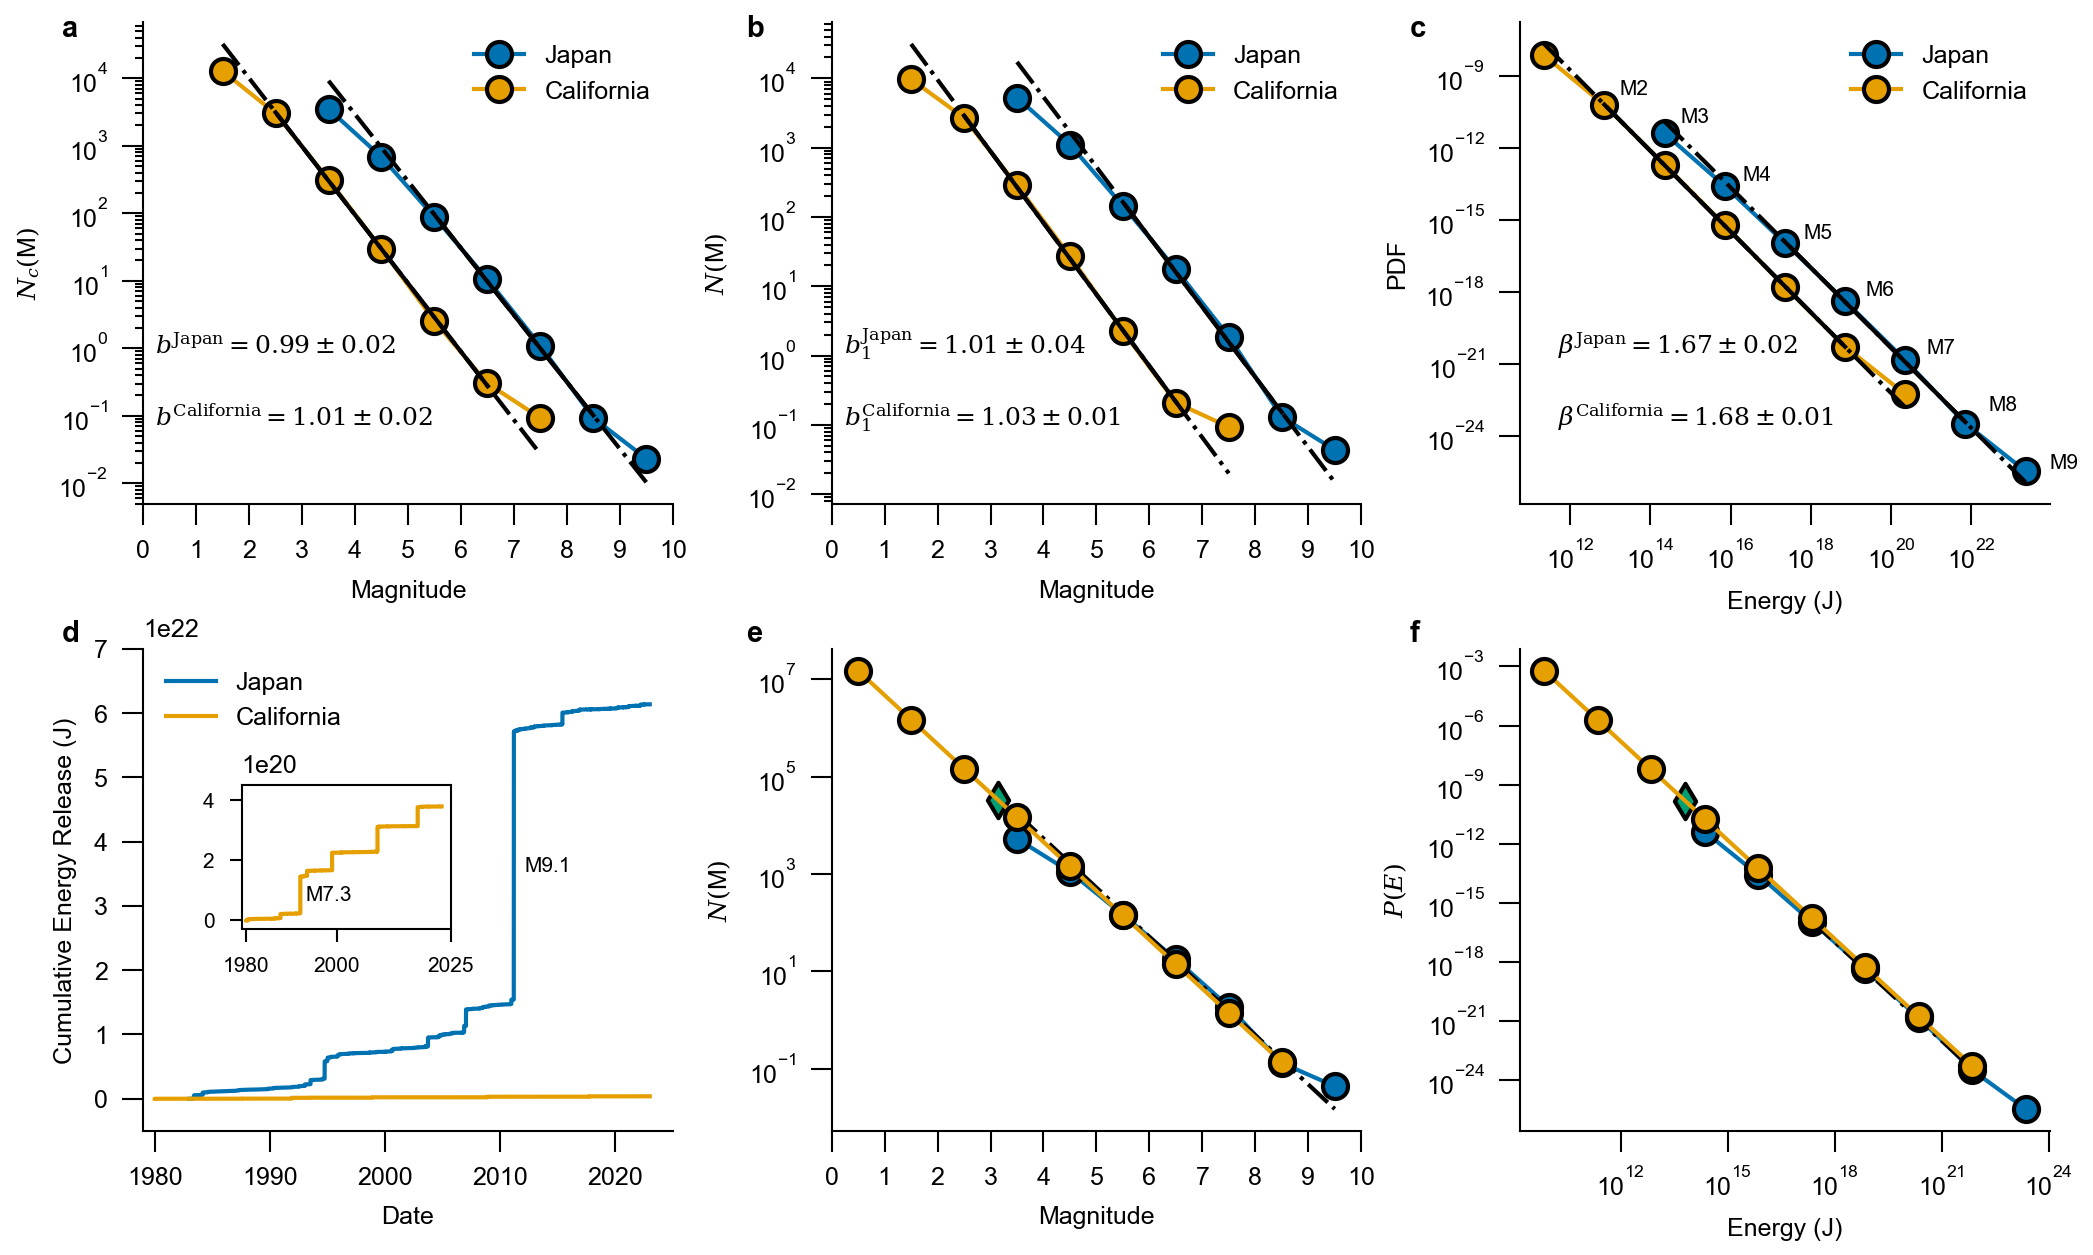

In [10]:

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

japan_ratio = 23
cal_ratio = 43
import sciplotlib.style as spstyle
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3, figsize = (8.2,4.8))
    
    mask = N_sup_m_jap!=0
    ax1.plot(distMAG_jap[:, 1][mask], N_sup_m_jap[mask], marker = 'o', color = color_list[5], label = 'Japan')
    ax1.plot(fitx_cdf_jap, fity_cdf_jap, ls = '-.', c = 'k')
    ax1.plot(fitx_cdf_jap[2:6], fity_cdf_jap[2:6], c = 'k')
    mask = N_sup_m_cal!=0
    ax1.plot(distMAG_cal[:, 1][mask], N_sup_m_cal[mask], marker = 'o', color = color_list[1], label = 'California')
    ax1.plot(fitx_cdf_cal, fity_cdf_cal, ls = '-.', c = 'k')
    ax1.plot(fitx_cdf_cal[1:6], fity_cdf_cal[1:6], c = 'k')
    
    ax2.plot(distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio, ls = '-', color = color_list[5], marker = 'o', label = 'Japan')
    ax2.plot(distMAG_cal[:, 1], distMAG_cal[:, 0] / cal_ratio, ls = '-', color = color_list[1], marker = 'o', label = 'California')
    ax2.plot(fitx_mag_jap[2:6], fity_mag_jap[2:6], c = 'k')
    ax2.plot(fitx_mag_jap, fity_mag_jap, c = 'k', ls ='-.')
    ax2.plot(fitx_mag_cal[1:6], fity_mag_cal[1:6], c = 'k')
    ax2.plot(fitx_mag_cal, fity_mag_cal, c = 'k', ls ='-.')
    
    mask = distMAGMom_cal[:, 0]!= 0
    ax3.plot(distMAGMom_jap[:, 1], distMAGMom_jap[:, 0] / japan_ratio, ls = '-', color = color_list[5], marker = 'o', label = 'Japan')
    ax3.plot(distMAGMom_cal[mask][:, 1], distMAGMom_cal[mask][:, 0] / cal_ratio, ls = '-', color = color_list[1], marker = 'o', label = 'California')
    ax3.plot(fitx_jap, fity_jap, '-.k')
    ax3.plot(fitx_jap[2:6], fity_jap[2:6], '-', color='k')
    ax3.plot(fitx_cal[1:6], fity_cal[1:6], '-k')
    ax3.plot(fitx_cal[:], fity_cal[:], '-.', color='k')
    
    ax4.plot(SMR1_jap[::10, 0], SMR1_jap[::10, 1], color = color_list[5], label = 'Japan')
    ax4.plot(SMR1_cal[::10, 0], SMR1_cal[::10, 1], color = color_list[1], label = 'California')
    
    ax42 = fig.add_axes([0.165, 0.25, 0.085, 0.1])
    ax42.plot(SMR1_cal[:, 0], SMR1_cal[:, 1], color = color_list[1])
    
    ax5.plot(distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio, ls = '-', color = color_list[5], marker = 'o', label = 'Japan')
    ax5.plot(fitx_mag_jap, fity_mag_jap, ls = '-.', c = 'k')
    # ax5.plot(distMAG_cal[:, 1], distMAG_cal[:, 0] / 43, ls = '-', color = color_list[1], marker = 'o', label = 'California')
    # ax5.plot(fitx_cdf_cal, fity_cdf_cal, ls = '-.', c = 'k')
    
    ax5.plot(magnitude_x, magnitude_y, '-o', lw=1, label=f'tau={tau:.2f}', color = color_list[1])
    ax5.scatter(mean_magnitude_x, mean_magnitude_y, marker = "d", c = color_list[3])
    
    ax6.plot(distMAGMom_jap[:, 1], distMAGMom_jap[:, 0] / japan_ratio, ls = '-', color = color_list[5], marker = 'o', label = 'Japan')
    ax6.plot(fitx_jap[2:6], fity_jap[2:6], '-.k')
    ax6.plot(E, P_E, '-o', lw=1, label=f'tau={tau:.2f}', color = color_list[1])
    ax6.scatter(mean_energy_x, mean_energy_y, marker = "d", c = color_list[3])
    
    
    ax1.set_yscale('log')
    ax1.set_xlabel('Magnitude')
    # ax1.set_ylabel("Cumulative distribution function")
    ax1.set_ylabel(r'$N_c($M$)$')
    ax1.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9,10])
    ax1.legend(loc = 'upper right')
    
    ax2.set_yscale('log')
    ax2.set_xlabel('Magnitude')
    # ax2.set_ylabel('Number of Earthquakes / year')
    ax2.set_ylabel(r'$N($M$)$')
    ax2.legend(loc = 'upper right')
    ax2.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9,10])
    
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_xlabel('Energy (J)')
    ax3.set_ylabel('PDF')
    ax3.legend(loc = 'upper right')

    ax4.axis([1979, 2025, -5e21, 7e22])
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Cumulative Energy Release (J)')
    ax4.legend(loc = 'upper left')


    ax42.axis([1979, 2025, -3e19, 4.5e20])
    ax42.spines['top'].set_visible(True)
    ax42.spines['right'].set_visible(True)
    ax42.tick_params(labelsize = 5, length = 3, which = "major")
    ax42.xaxis.set_ticks([1980, 2000, 2025])
    
    ax5.set_xlabel('Magnitude')
    # ax5.set_ylabel('Number of Earthquakes / year')
    ax5.set_ylabel(r'$N($M$)$')
    ax5.set_yscale('log')
    ax5.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9,10])
    
    ax6.set_xlabel('Energy (J)')
    ax6.set_ylabel(r'$P(E)$')
    ax6.set_xscale('log')
    ax6.set_yscale('log')
    
    
    fig.text(0.13, 0.65, r"$b^{} = {}\pm {}$".format("\mathrm{Japan}", np.round(-exp_cdf_jap,2), np.round(err_cdf_jap,2)), fontsize=6) 
    fig.text(0.13, 0.6, r"$b^{} = {}\pm {}$".format("\mathrm{California}", np.round(-exp_cdf_cal,2), np.round(err_cdf_cal,2)), fontsize=6)
    
    fig.text(0.41, 0.65, r"$b^{}_1 = {}\pm {}$".format("\mathrm{Japan}", np.round(-b_jap,2), np.round(err_b_jap,2)), fontsize=6) 
    fig.text(0.41, 0.6, r"$b^{}_1 = {}\pm {}$".format("\mathrm{California}", np.round(-b_cal,2), np.round(err_b_cal,2)), fontsize=6) 
    
    fig.text(0.70, 0.65, r"$\beta^{} = {} \pm {}$".format("\mathrm{Japan}", np.round(-beta_jap,2), np.round(err_beta_jap,2)), fontsize=6) 
    fig.text(0.70, 0.6, r"$\beta^{} = {}\pm {}$".format("\mathrm{California}", np.round(-beta_cal,2) ,np.round(err_beta_cal,2)), fontsize=6) 
    fig.text(0.725, 0.83, 'M2', fontsize=5)
    fig.text(0.75, 0.81, 'M3', fontsize=5) 
    fig.text(0.775, 0.77, 'M4', fontsize=5) 
    fig.text(0.8, 0.73, 'M5', fontsize=5) 
    fig.text(0.825, 0.69, 'M6', fontsize=5) 
    fig.text(0.850, 0.65, 'M7', fontsize=5) 
    fig.text(0.875, 0.61, 'M8', fontsize=5) 
    fig.text(0.9, 0.57, 'M9', fontsize=5)
    
    fig.text(0.28, 0.29, 'M9.1', fontsize=5) 
    fig.text(0.191, 0.27, 'M7.3', fontsize=5)
    
    fig.text(0.092, 0.87, 'a', fontsize=7, fontweight="bold")
    fig.text(0.37, 0.87, 'b', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.87, 'c', fontsize=7, fontweight="bold") 
    fig.text(0.092, 0.45, 'd', fontsize=7, fontweight="bold") 
    fig.text(0.37, 0.45, 'e', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.45, 'f', fontsize=7, fontweight="bold") 
    
    fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax3.patch.set_alpha(0.0)
    ax4.patch.set_alpha(0.0)
    ax42.patch.set_alpha(0.0)
    ax5.patch.set_alpha(0.0)
    ax6.patch.set_alpha(0.0)
    fig.savefig('Fig1.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()
    

#   Figure 2 (N cst)

In [3]:
#%% Paramètres d'énergie
Emax = energy(8.9)  # MagMax=9.1
Emin = energy(0)          # MagMin=6.07
Etot = 6.5297e+22 / 40 
# Etot = 6.5297e+22 * 0.37 / 40         # Total yearly energy excluding tohoku 
print('Etot: ', Etot)


#tau_values = np.array([(n + 7) / 10 for n in range(18)])
tau_values = np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.67, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2])
b_values = (tau_values - 1)*3/2
# Init array
nbins = 9

ntot = len(tau_values)
Sum001 = np.zeros(ntot)

P_E = np.zeros((ntot, nbins))

norm_P_E = np.zeros((ntot, nbins))

mean_energy = np.zeros(ntot)
mean_energy_y = np.zeros(ntot)
norm_mean_energy_y = np.zeros(ntot)

magnitude_y = np.zeros((ntot, nbins))
mag_norm_y = np.zeros((ntot, nbins))
mean_magnitude_x = np.zeros(ntot)
mean_magnitude_y = np.zeros(ntot)

P_energy8 = np.zeros(ntot)
P_energy0 = np.zeros(ntot)

Ntot = np.zeros(ntot)
Etot2 = np.zeros(ntot)

cdf_magnitude_y = np.zeros((ntot, nbins+1))
magnitude_edge_x = np.linspace(0,9,nbins+1)
b1_values = np.zeros(ntot)
N8 = np.zeros(ntot)



magnitude_x = np.linspace(0,8,nbins) + 0.5
energy_edges = energy(np.linspace(0, 8.9, nbins+1))
E = np.array(10 ** (1.5 * (magnitude_x + 6.07)))


# print(energy_edges)
# print(energy_center)
# print(magnitude_x)

tau_EQ = 1.67
k_orig_ref8 = Etot * (2 - tau_EQ) / (Emax ** (2 - tau_EQ) - Emin ** (2 - tau_EQ))
N_ref_tot = k_orig_ref8 * ( (energy(8.9)**(1-tau_EQ)) - (energy(0)**(1-tau_EQ)) )/(1 - tau_EQ)
E_ref_tot = k_orig_ref8 * ( (energy(8.9)**(2-tau_EQ)) - (energy(0)**(2-tau_EQ)) )/(2 - tau_EQ) #Recalc Etot 

# N_tot_ref=9183139 #nb EQ
print("E tot recalc", E_ref_tot)
print("N tot recalc", N_ref_tot)


for n in range(ntot):
    tau = tau_values[n]
    if tau == 2:
        tau = 2.0000001  # éviter division par zéro
        tau_values[n] = tau

    #Without normalisation
    dE = energy_edges[1:] - energy_edges[:-1]
    
    k_orig = N_ref_tot / np.sum(E**(-tau) * dE) #constant Activity Ntot
    # print("k_N: ", k_orig)
    # k_orig = Etot / np.sum(E**(1-tau) * dE) #Constant Energy E_tot
    # print("k_E: ", k_orig)
    P_E[n] = k_orig * E ** (-tau) 
    # P_E_edge[n] = k_orig * energy_edges ** (-tau)
    
    #With normalisation
    Ntot[n] = np.sum(P_E[n]*dE) 
    N8[n] = P_E[n][magnitude_x == 8.5] *dE[magnitude_x == 8.5]
    Etot2[n] = np.sum(P_E[n] * dE * E)
    norm_P_E[n] = P_E[n]/Ntot[n]
    """ check_norm = np.sum(norm_line01y[n] * dE)
    print("Test normalisation: ", check_norm) """
    
    mean_energy[n] = np.sum(E * norm_P_E[n] * dE)
    mean_energy_y[n] = k_orig * mean_energy[n] ** (-tau)
    """ norm_mean_energy_y[n] = k_orig/Ntot[n] * mean_energy[n] ** (-tau) """
    
    
    #Magnitude, largeur des bins = 1
    magnitude_y[n] = P_E[n] * 1.5 * np.log(10) * E
    # mag_norm_y[n] = magnitude_y[n]/np.sum(magnitude_y[n]) 
    
    """ mean_magnitude_x[n] = np.sum(magnitude_x * mag_norm_y[n])# Moyenne des magnitude """
    mean_magnitude_x[n]= magnitude(mean_energy[n]) #Moyenne des energies en magnitude

    yE_mag = k_orig *  mean_energy[n] ** (-tau)
    mean_magnitude_y[n] = yE_mag * 1.5 * np.log(10) *  mean_energy[n]
    
    """ check_norm_mag = np.sum(mag_norm_y[n])
    print("Tes norm mag: ", check_norm_mag) """
    
    #Cumulative distribution
    SUM = np.sum(magnitude_y[n])
    cdf_magnitude_y[n, :-1] = np.array([(SUM - np.sum(magnitude_y[n, :i]))/SUM for i in range(nbins)])

    Fitx = magnitude_x
    Fity = np.log10(cdf_magnitude_y[n, :-1])

    popt, pcov = curve_fit(expfct2, Fitx[:], Fity[:], maxfev = 1000)
    b1_values[n] = -popt[1]
    
    #Pourcentage d'énergie comptenu dans une gamme de magnitude
    P_energy8[n] = E[-1] * dE[-1] * P_E[n][-1]/np.sum(E*P_E[n]*dE)
    P_energy0[n] = E[0] * dE[0] * P_E[n][0]/np.sum(E*P_E[n]*dE)

    
rate_per_min = N8/(365*24*60)
print("Etot: ", Etot2)
print("Ntot: ", Ntot)

popt, pcov = curve_fit(linlaw, b1_values[7:], b_values[7:], maxfev = 1000)
print(popt)
y_fit_b = linlaw(b1_values, *popt)




Etot:  1.6324249999999998e+21
E tot recalc 1.6324249999999998e+21
N tot recalc 24819295.29526159
Etot:  [1.13547335e+29 8.68457584e+28 5.13462407e+28 1.74285402e+28
 2.84737988e+27 2.88791044e+26 2.38383370e+25 1.80787945e+24
 1.32944025e+23 9.81141994e+21 1.61623909e+21 7.53733000e+20
 6.41953924e+19 7.02873707e+18 1.33681958e+18 5.28423701e+17
 3.37627155e+17]
Ntot:  [24819295.29526159 24819295.29526159 24819295.29526159 24819295.29526159
 24819295.29526159 24819295.29526159 24819295.29526159 24819295.29526159
 24819295.29526159 24819295.2952616  24819295.29526159 24819295.29526159
 24819295.29526159 24819295.2952616  24819295.29526159 24819295.29526159
 24819295.29526159]
[ 1.00677902 -0.01129696]


/tmp/ipykernel_1194408/4101573894.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


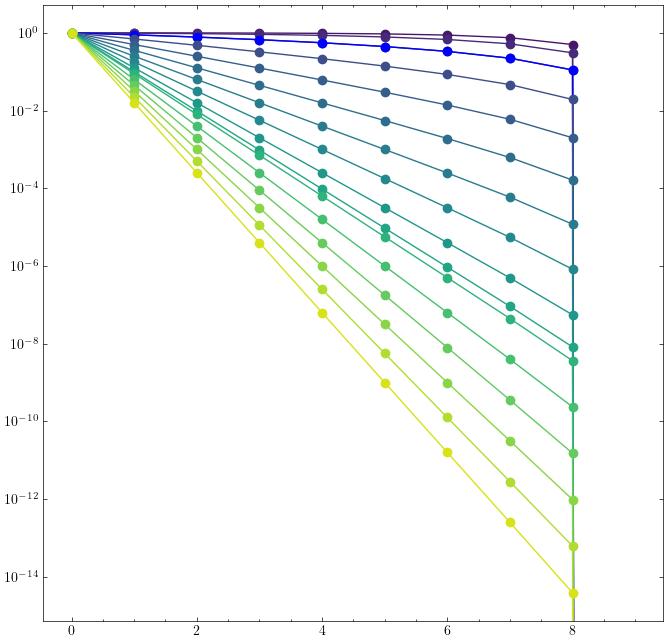

In [4]:
NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
fig, ax = plt.subplots(figsize = (8,8))
for n in range(1,ntot):
    ax.plot(magnitude_edge_x, cdf_magnitude_y[n], marker = 'o',c = colors[n])
    if tau_values[n] in [1.0]:
        ax.plot(magnitude_edge_x, cdf_magnitude_y[n], marker = 'o',c = 'b')

ax.set_yscale('log')
plt.show()

/tmp/ipykernel_1194408/697616600.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


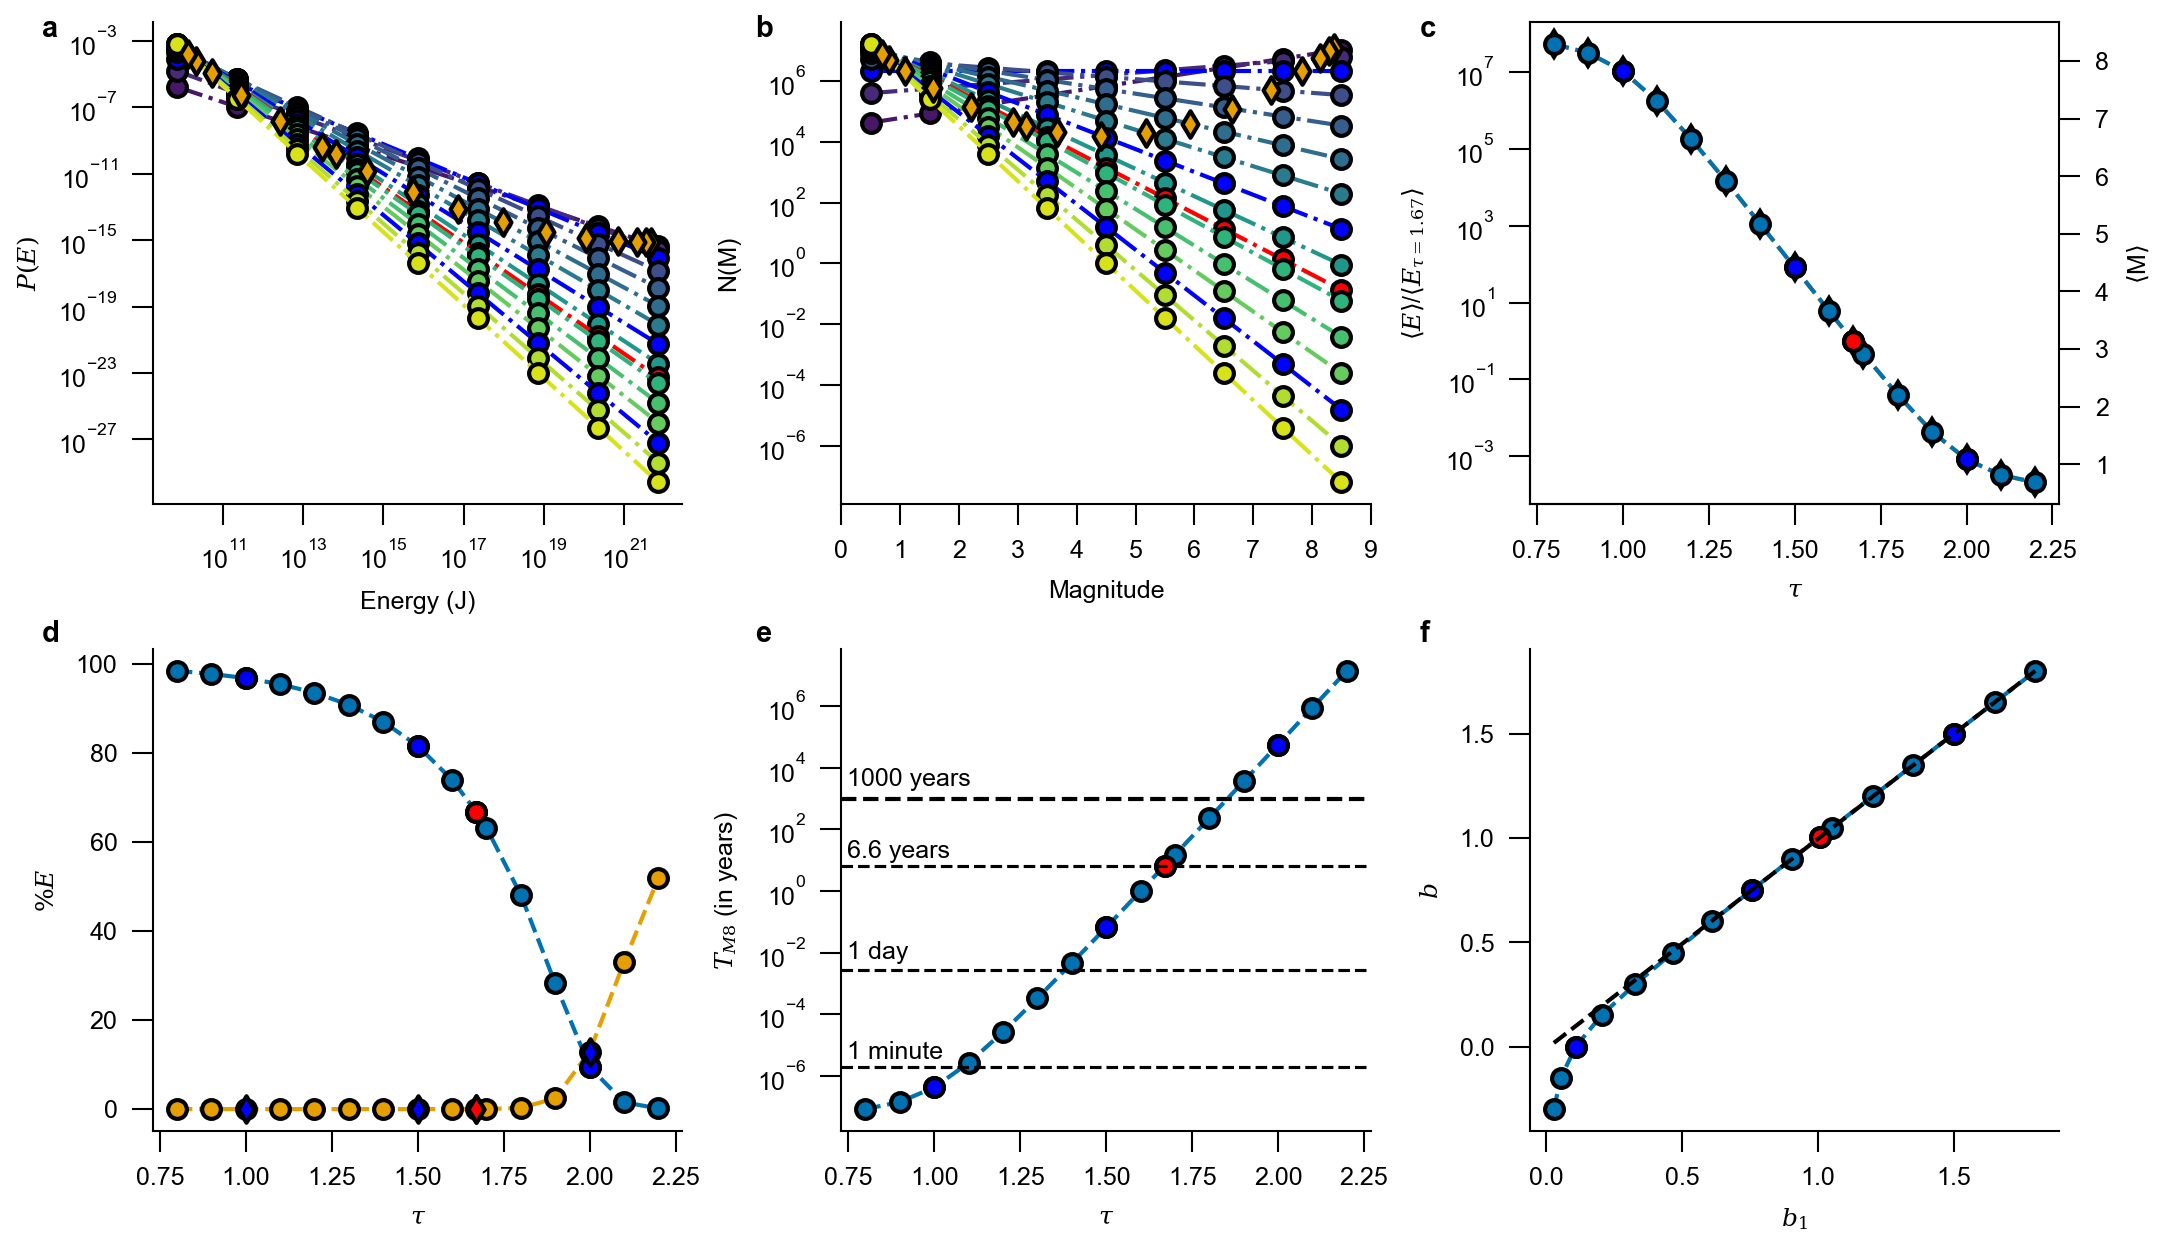

In [5]:

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    plt.rc('lines', markersize=4.5)
    
    fig, axs = plt.subplots(2,3, figsize = (8.2, 4.8))
    ax1 = axs[0, 0]
    ax2 = axs[0, 1]
    ax3 = axs[0, 2]
    ax4 = axs[1, 0]
    ax5 = axs[1, 1]
    ax6 = axs[1, 2]
    ax32 = ax3.twinx()

    for n in range(1,ntot):
        if tau_values[n] in [1.0, 1.5,2.0000001]:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',label=f'tau={tau_values[n]:.2f}', c = 'b')
        elif tau_values[n] == 1.67:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
        else:
            ax1.plot(E, P_E[n], '-.o', c = colors[n], linewidth=1)
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',  c = colors[n], linewidth=1)
            
    ax1.scatter(mean_energy, mean_energy_y, marker = 'd', c = color_list[1], zorder = 10)  # point moyen
    ax2.scatter(mean_magnitude_x, mean_magnitude_y, marker = 'd', c = color_list[1], zorder = 10)

    ax3.plot(tau_values[1::1], mean_energy[1::1]/mean_energy[tau_values==1.67], c = color_list[1], marker = 'd', ls = '--')
    mask = np.isin(tau_values, [1.0, 1.5, 1.67, 2.0000001])
    ax32.plot(tau_values[1::1], mean_magnitude_x[1::1], c = color_list[5], marker = 'o', ls = '--')
    ax32.scatter(tau_values[mask], mean_magnitude_x[mask], c = 'b', zorder = 10)
    ax32.scatter(tau_values[tau_values==1.67], mean_magnitude_x[tau_values==1.67], c = 'r', zorder = 10)

    
    ax4.plot(tau_values[1::1], P_energy8[1::1]*100, c = color_list[5], marker = 'o', ls = '--')
    ax4.plot(tau_values[1::1], P_energy0[1::1]*100, c = color_list[1], marker = 'o',ls = '--')
    ax4.scatter(tau_values[mask], P_energy8[mask]*100, marker = 'o', c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy8[tau_values==1.67]*100, marker = 'o', c = 'r', zorder = 10)
    ax4.scatter(tau_values[mask], P_energy0[mask]*100, marker = 'd', c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy0[tau_values==1.67]*100, marker = 'd', c = 'r', zorder = 10)
    
    mask = [3,8,14]
    # ax6.scatter(tau_values[1:], b_values[1:]/b1_values[1:], marker = 'o', c = color_list[5])
    # ax6.scatter(tau_values[mask], b_values[mask]/b1_values[mask], marker = 'o', c = 'b')
    # ax6.scatter(tau_values[10], b_values[10]/b1_values[10], marker = 'o', c = 'r')
    
    ax6.plot(b1_values[1:], b_values[1:], marker = 'o', c = color_list[5], ls = '--')
    ax6.scatter(b1_values[mask], b_values[mask], marker = 'o', c = 'b', zorder = 2)
    ax6.scatter(b1_values[10], b_values[10], marker = 'o', c = 'r', zorder = 2)
    ax6.plot(b1_values[1:], y_fit_b[1:], ls = '--', c = 'k')
    
    ax5.plot(tau_values[1:], 1/N8[1:], c = color_list[5], marker = 'o', ls = '--')
    ax5.scatter(tau_values[mask],  1/N8[mask], marker = 'o', c = 'b', zorder = 2)
    ax5.scatter(tau_values[10],  1/N8[10], marker = 'o', c = 'r', zorder = 2)
    
    ax5.axhline(1000, c = 'k', ls= '--')
    # ax5.axhline(100, c = 'k', ls= '--')
    # ax5.axhline(1, c = 'k', ls= '--')
    ax5.axhline(1/N8[10], c = 'k', ls= '--', lw = 0.75)
    # ax5.axhline(1/12, c = 'k', ls= '--')
    ax5.axhline(1/365, c = 'k', ls= '--', lw = 0.75)
    # ax5.axhline(1/(365*24), c = 'k', ls= '--')
    ax5.axhline(1/(365*24*60), c = 'k', ls= '--', lw = 0.75)

    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel(r'$P(E)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('N(M)')
    ax2.set_yscale('log')
    ax2.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9])

    ax3.set_xlabel(r'$\tau$')
    ax3.set_ylabel(r'$\langle E \rangle$/$\langle E_{\tau = 1.67} \rangle$')
    ax3.set_yscale('log')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    # ax32.set_ylabel('<M>')
    #ax32.set_yscale('log')
    ax32.set_ylabel(r'$\langle$M$\rangle$')

    
    ax4.set_xlabel(r'$\tau$')
    ax4.set_ylabel(r'$\%E$')
    
    # ax6.set_ylim(0.6,1.1)
    # ax6.yaxis.set_ticks([-11,-9,-7,-5,-3,-1,1])
    # ax6.set_xlabel(r'$\tau$')
    # ax6.set_ylabel(r"$b/b_1$")
    ax6.set_xlabel(r'$b_1$')
    ax6.set_ylabel(r"$b$")
    
    ax5.set_xlabel(r'$\tau$')
    ax5.set_ylabel(r"$T_{M8}$ (in years)")
    ax5.set_yscale('log')
    # ax5.set_yscale('log')
    #ax4.set_yscale('log')
    # ax4.spines['top'].set_visible(True)
    # ax4.spines['right'].set_visible(True)
    #ax62.set_yscale('log')
    
    fig.text(0.08, 0.87, 'a', fontsize=7, fontweight="bold")
    fig.text(0.37, 0.87, 'b', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.87, 'c', fontsize=7, fontweight="bold") 
    fig.text(0.08, 0.45, 'd', fontsize=7, fontweight="bold") 
    fig.text(0.37, 0.45, 'e', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.45, 'f', fontsize=7, fontweight="bold") 
    
    fig.text(0.407, 0.35, '1000 years')
    fig.text(0.407, 0.30, '{} years'.format(np.round(1/N8[10], 1)))
    fig.text(0.407, 0.23, '1 day')
    fig.text(0.407, 0.16, '1 minute')
    
    fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
    
    fig.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax3.patch.set_alpha(0.0)
    ax4.patch.set_alpha(0.0)
    ax5.patch.set_alpha(0.0)
    ax6.patch.set_alpha(0.0)
    fig.savefig('Fig2.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()


In [6]:
print(tau_values[1:])
print(mean_energy[:]/mean_energy[tau_values==1.67])
print(P_energy8[:])
print((1/N8[:]))


[0.8       0.9       1.        1.1       1.2       1.3       1.4
 1.5       1.6       1.67      1.7       1.8       1.9       2.0000001
 2.1       2.2      ]
[7.02540455e+07 5.37332372e+07 3.17689635e+07 1.07833923e+07
 1.76173185e+06 1.78680893e+05 1.47492640e+04 1.11857179e+03
 8.22551725e+01 6.07052508e+00 1.00000000e+00 4.66349938e-01
 3.97189950e-02 4.34882259e-03 8.27117466e-04 3.26946492e-04
 2.08896788e-04]
[0.98834086 0.98353102 0.97673695 0.96714007 0.95358411 0.93443582
 0.90738813 0.86918226 0.81521523 0.73898843 0.66762875 0.63138498
 0.48055957 0.28216089 0.09483318 0.01527619 0.00151825]
[6.38140499e-08 8.38423273e-08 1.42795240e-07 4.24863685e-07
 2.63751891e-06 2.65379153e-05 3.31078480e-04 4.55742653e-03
 6.60783050e-02 9.87712373e-01 6.63680965e+00 1.50483271e+01
 2.32139430e+02 3.61098662e+03 5.64893917e+04 8.87161610e+05
 1.39707230e+07]


In [7]:
print(tau_values[1:])
print(mean_energy[9]/mean_energy[tau_values==1.67])
print(mean_energy[13]/mean_energy[tau_values==1.67])
print(P_energy8[9])
print((1/N8[9])*365 )
print(P_energy8[13])
print((1/N8[13]) )

[0.8       0.9       1.        1.1       1.2       1.3       1.4
 1.5       1.6       1.67      1.7       1.8       1.9       2.0000001
 2.1       2.2      ]
[6.07052508]
[0.00434882]
0.7389884340690999
360.51501631634034
0.28216089440537656
3610.986618133305


#   Figure 3 (E cst)

In [3]:
#%% Paramètres d'énergie
Emax = energy(8.9)  # MagMax=9.1
Emin = energy(0)          # MagMin=6.07
Etot = 6.5297e+22 / 40 
# Etot = 6.5297e+22 * 0.37 / 40         # Total yearly energy excluding tohoku 
print('Etot: ', Etot)


#tau_values = np.array([(n + 7) / 10 for n in range(18)])
tau_values = np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.67, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2])
b_values = (tau_values - 1)*3/2
# Init array
nbins = 9

ntot = len(tau_values)
Sum001 = np.zeros(ntot)

P_E = np.zeros((ntot, nbins))

norm_P_E = np.zeros((ntot, nbins))

mean_energy = np.zeros(ntot)
mean_energy_y = np.zeros(ntot)
norm_mean_energy_y = np.zeros(ntot)

magnitude_y = np.zeros((ntot, nbins))
mag_norm_y = np.zeros((ntot, nbins))
mean_magnitude_x = np.zeros(ntot)
mean_magnitude_y = np.zeros(ntot)

P_energy8 = np.zeros(ntot)
P_energy0 = np.zeros(ntot)

Ntot = np.zeros(ntot)
Etot2 = np.zeros(ntot)

cdf_magnitude_y = np.zeros((ntot, nbins+1))
magnitude_edge_x = np.linspace(0,9,nbins+1)
b1_values = np.zeros(ntot)
N8 = np.zeros(ntot)



magnitude_x = np.linspace(0,8,nbins) + 0.5
energy_edges = energy(np.linspace(0, 8.9, nbins+1))
E = np.array(10 ** (1.5 * (magnitude_x + 6.07)))


# print(energy_edges)
# print(energy_center)
# print(magnitude_x)

tau_EQ = 1.67
k_orig_ref8 = Etot * (2 - tau_EQ) / (Emax ** (2 - tau_EQ) - Emin ** (2 - tau_EQ))
N_ref_tot = k_orig_ref8 * ( (energy(8.9)**(1-tau_EQ)) - (energy(0)**(1-tau_EQ)) )/(1 - tau_EQ)
E_ref_tot = k_orig_ref8 * ( (energy(8.9)**(2-tau_EQ)) - (energy(0)**(2-tau_EQ)) )/(2 - tau_EQ) #Recalc Etot 

# N_tot_ref=9183139 #nb EQ
print("E tot recalc", E_ref_tot)
print("N tot recalc", N_ref_tot)


for n in range(ntot):
    tau = tau_values[n]
    if tau == 2:
        tau = 2.0000001  # éviter division par zéro
        tau_values[n] = tau

    #Without normalisation
    dE = energy_edges[1:] - energy_edges[:-1]
    
    # k_orig = N_ref_tot / np.sum(E**(-tau) * dE) #constant Activity Ntot
    # print("k_N: ", k_orig)
    k_orig = Etot / np.sum(E**(1-tau) * dE) #Constant Energy E_tot
    # print("k_E: ", k_orig)
    P_E[n] = k_orig * E ** (-tau) 
    # P_E_edge[n] = k_orig * energy_edges ** (-tau)
    
    #With normalisation
    Ntot[n] = np.sum(P_E[n]*dE) 
    N8[n] = P_E[n][magnitude_x == 8.5] *dE[magnitude_x == 8.5]
    Etot2[n] = np.sum(P_E[n] * dE * E)
    norm_P_E[n] = P_E[n]/Ntot[n]
    """ check_norm = np.sum(norm_line01y[n] * dE)
    print("Test normalisation: ", check_norm) """
    
    mean_energy[n] = np.sum(E * norm_P_E[n] * dE)
    mean_energy_y[n] = k_orig * mean_energy[n] ** (-tau)
    """ norm_mean_energy_y[n] = k_orig/Ntot[n] * mean_energy[n] ** (-tau) """
    
    
    #Magnitude, largeur des bins = 1
    magnitude_y[n] = P_E[n] * 1.5 * np.log(10) * E
    # mag_norm_y[n] = magnitude_y[n]/np.sum(magnitude_y[n]) 
    
    """ mean_magnitude_x[n] = np.sum(magnitude_x * mag_norm_y[n])# Moyenne des magnitude """
    mean_magnitude_x[n]= magnitude(mean_energy[n]) #Moyenne des energies en magnitude

    yE_mag = k_orig *  mean_energy[n] ** (-tau)
    mean_magnitude_y[n] = yE_mag * 1.5 * np.log(10) *  mean_energy[n]
    
    """ check_norm_mag = np.sum(mag_norm_y[n])
    print("Tes norm mag: ", check_norm_mag) """
    
    #Cumulative distribution
    SUM = np.sum(magnitude_y[n])
    cdf_magnitude_y[n, :-1] = np.array([(SUM - np.sum(magnitude_y[n, :i]))/SUM for i in range(nbins)])

    Fitx = magnitude_x
    Fity = np.log10(cdf_magnitude_y[n, :-1])

    popt, pcov = curve_fit(expfct2, Fitx[:], Fity[:], maxfev = 1000)
    b1_values[n] = -popt[1]
    
    #Pourcentage d'énergie comptenu dans une gamme de magnitude
    P_energy8[n] = E[-1] * dE[-1] * P_E[n][-1]/np.sum(E*P_E[n]*dE)
    P_energy0[n] = E[0] * dE[0] * P_E[n][0]/np.sum(E*P_E[n]*dE)
    
    # print(np.sum(E**(1-tau) * dE)/np.sum(E**(-tau) * dE))
    # print(mean_energy[n])

    
rate_per_min = N8/(365*24*60)
print("Etot: ", Etot2)
print("Ntot: ", Ntot)

popt, pcov = curve_fit(linlaw, b1_values[7:], b_values[7:], maxfev = 1000)
print(popt)
y_fit_b = linlaw(b1_values, *popt)




Etot:  1.6324249999999998e+21
E tot recalc 1.6324249999999998e+21
N tot recalc 24819295.29526159
Etot:  [1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21
 1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21
 1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21 1.632425e+21
 1.632425e+21 1.632425e+21]
Ntot:  [3.56817166e-01 4.66524086e-01 7.89067273e-01 2.32467193e+00
 1.42290948e+01 1.40293957e+02 1.69960003e+03 2.24105861e+04
 3.04757119e+05 4.12943676e+06 2.50678494e+07 5.37533028e+07
 6.31130002e+08 5.76428421e+09 3.03074841e+10 7.66726361e+10
 1.20001124e+11]
[ 1.00671756 -0.01123892]


/tmp/ipykernel_1193831/4101573894.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


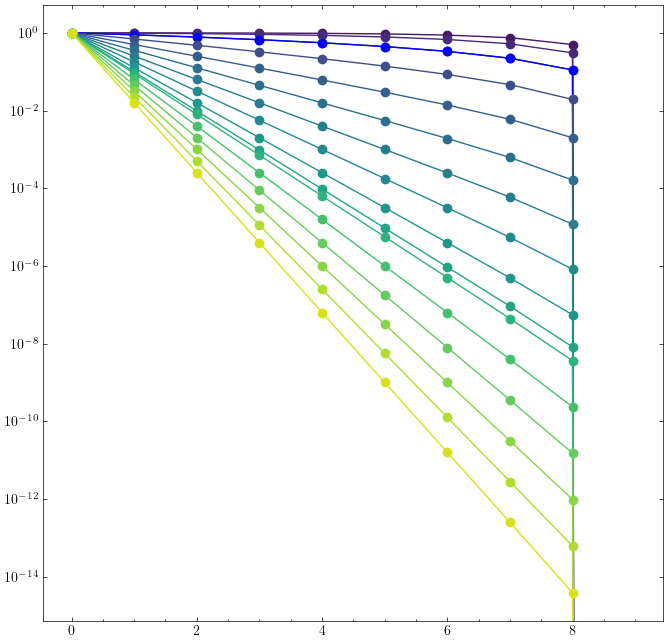

In [4]:
NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
fig, ax = plt.subplots(figsize = (8,8))
for n in range(1,ntot):
    ax.plot(magnitude_edge_x, cdf_magnitude_y[n], marker = 'o',c = colors[n])
    if tau_values[n] in [1.0]:
        ax.plot(magnitude_edge_x, cdf_magnitude_y[n], marker = 'o',c = 'b')

ax.set_yscale('log')
plt.show()

/tmp/ipykernel_1193831/808711456.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


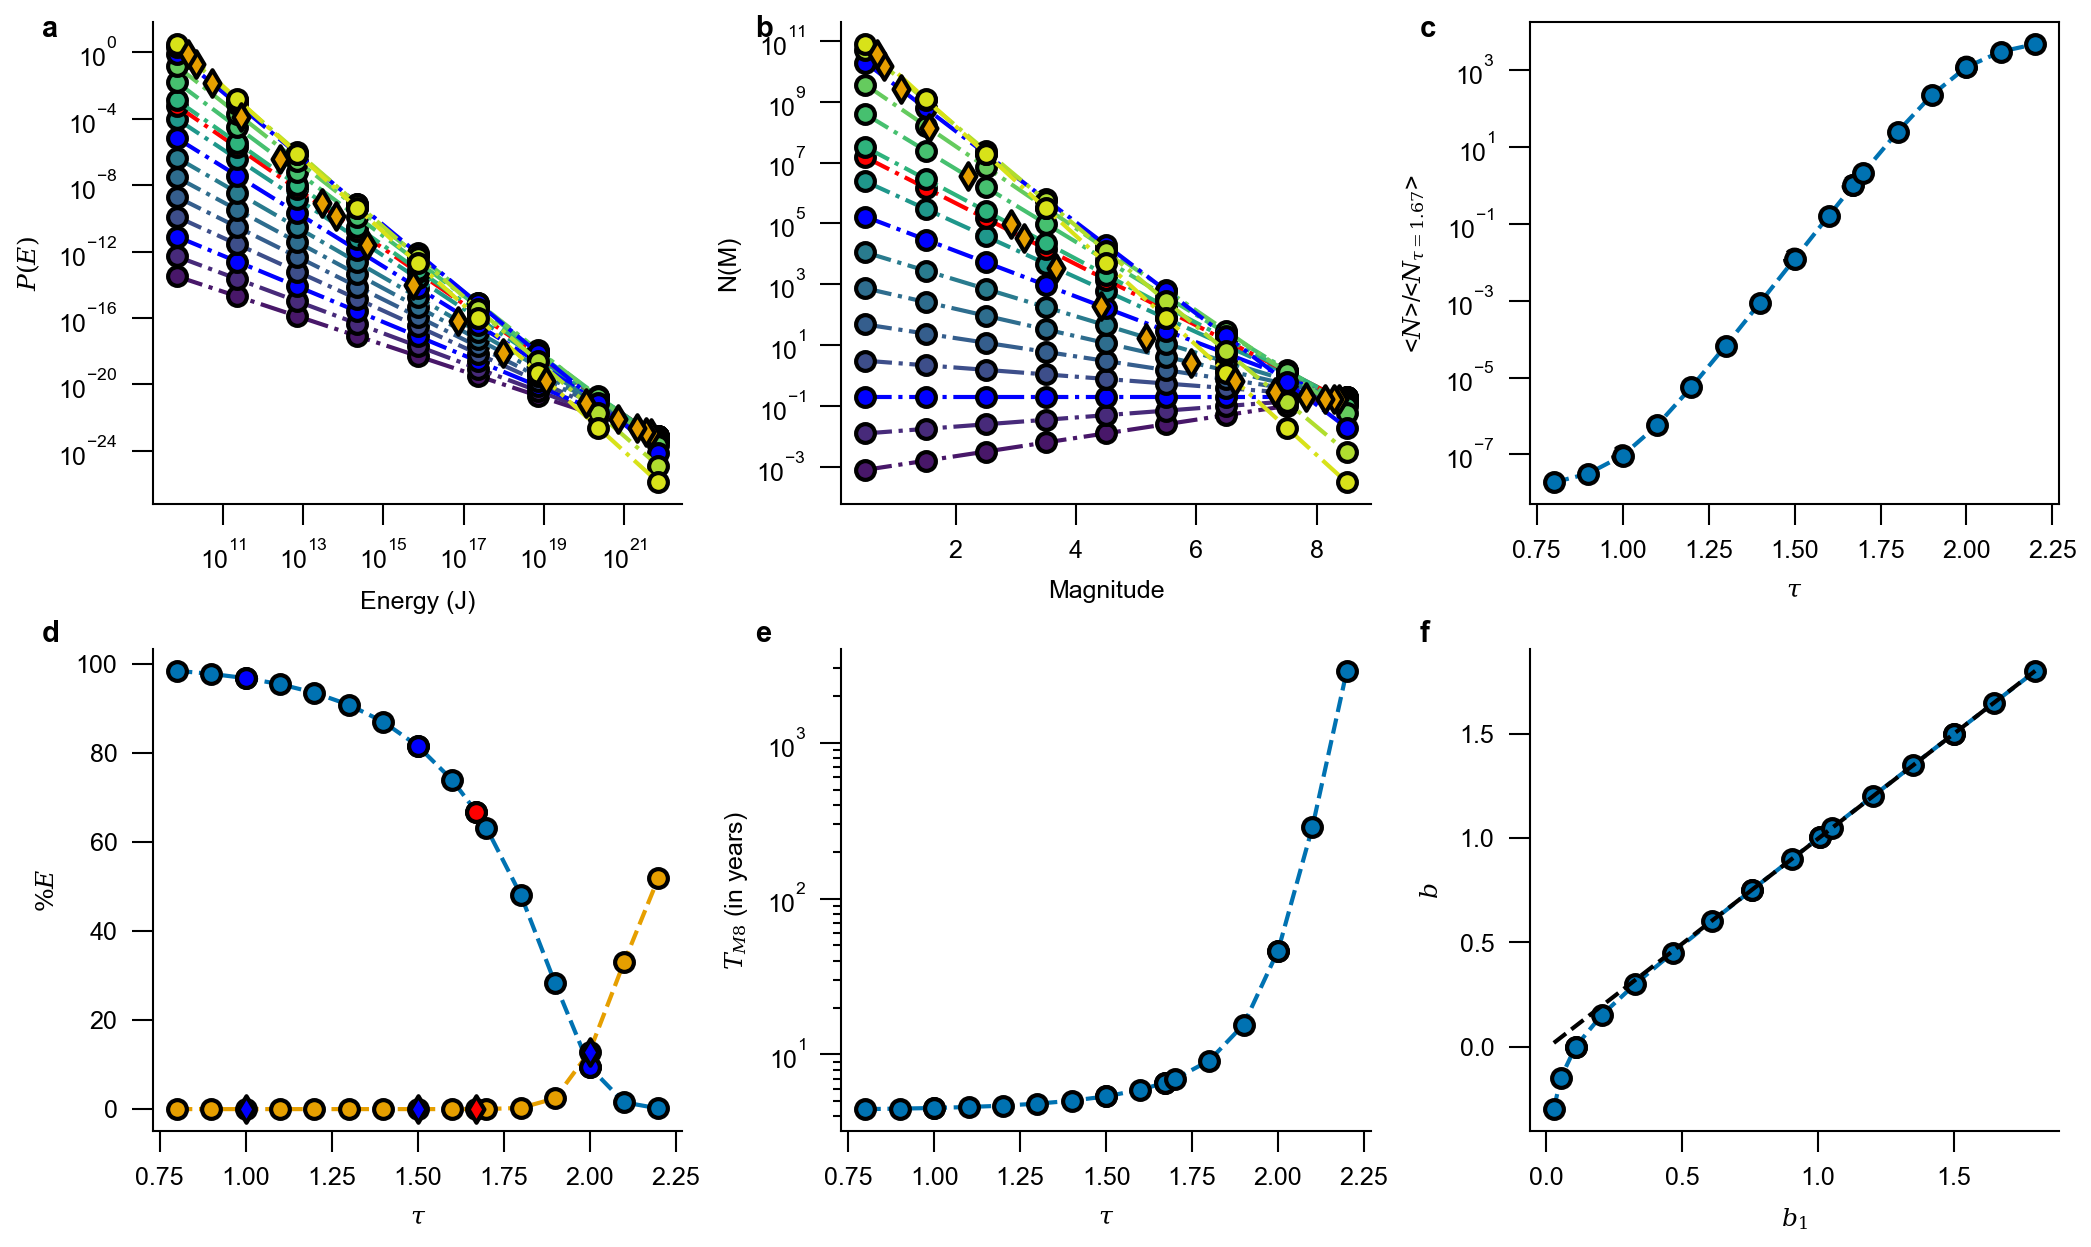

In [5]:

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    plt.rc('lines', markersize=4.5)
    
    fig, axs = plt.subplots(2,3, figsize = (8.2, 4.8))
    ax1 = axs[0, 0]
    ax2 = axs[0, 1]
    ax3 = axs[0, 2]
    ax4 = axs[1, 0]
    ax5 = axs[1, 1]
    ax6 = axs[1, 2]
    # ax32 = ax3.twinx()

    for n in range(1,ntot):
        if tau_values[n] in [1.0, 1.5,2.0000001]:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',label=f'tau={tau_values[n]:.2f}', c = 'b')
        elif tau_values[n] == 1.67:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
        else:
            ax1.plot(E, P_E[n], '-.o', c = colors[n], linewidth=1)
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',  c = colors[n], linewidth=1)
            
    ax1.scatter(mean_energy, mean_energy_y, marker = 'd', c = color_list[1], zorder = 10)  # point moyen
    ax2.scatter(mean_magnitude_x, mean_magnitude_y, marker = 'd', c = color_list[1], zorder = 10)

    ax3.plot(tau_values[1::1], Ntot[1::1]/Ntot[tau_values==1.67], c = color_list[5], marker = 'o', ls = '--')
    mask = np.isin(tau_values, [1.0, 1.5, 2.0000001])
    ax3.scatter(tau_values[mask], Ntot[mask]/Ntot[tau_values==1.67], c = 'b', marker = 'o', ls = '--')
    ax3.scatter(tau_values[tau_values==1.67], Ntot[tau_values==1.67]/Ntot[tau_values==1.67], c = 'r', marker = 'o', ls = '--')
    # ax32.plot(tau_values[1::1], mean_magnitude_x[1::1], c = color_list[5], marker = 'o', ls = '--')
    # ax32.scatter(tau_values[mask], mean_magnitude_x[mask], c = 'b', zorder = 10)
    # ax32.scatter(tau_values[tau_values==1.67], mean_magnitude_x[tau_values==1.67], c = 'r', zorder = 10)

    
    ax4.plot(tau_values[1::1], P_energy8[1::1]*100, c = color_list[5], marker = 'o', ls = '--')
    ax4.plot(tau_values[1::1], P_energy0[1::1]*100, c = color_list[1], marker = 'o',ls = '--')
    ax4.scatter(tau_values[mask], P_energy8[mask]*100, marker = 'o', c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy8[tau_values==1.67]*100, marker = 'o', c = 'r', zorder = 10)
    ax4.scatter(tau_values[mask], P_energy0[mask]*100, marker = 'd', c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy0[tau_values==1.67]*100, marker = 'd', c = 'r', zorder = 10)
    
    mask = [3,8,14]
    # ax6.scatter(tau_values[1:], b_values[1:]/b1_values[1:], marker = 'o', c = color_list[5])
    # ax6.scatter(tau_values[mask], b_values[mask]/b1_values[mask], marker = 'o', c = 'b')
    # ax6.scatter(tau_values[10], b_values[10]/b1_values[10], marker = 'o', c = 'r')
    
    ax6.plot(b1_values[1:], b_values[1:], marker = 'o', c = color_list[5], ls = '--')
    ax6.scatter(b1_values[mask], b_values[mask], marker = 'o', c = 'b')
    ax6.scatter(b1_values[10], b_values[10], marker = 'o', c = 'r')
    ax6.plot(b1_values[1:], y_fit_b[1:], ls = '--', c = 'k')
    
    ax5.plot(tau_values[1:], 1/N8[1:], c = color_list[5], marker = 'o', ls = '--')
    ax5.scatter(tau_values[mask],  1/N8[mask], marker = 'o', c = 'b')
    ax5.scatter(tau_values[10],  1/N8[10], marker = 'o', c = 'r')
    
    # ax5.axhline(1000, c = 'k', ls= '--')
    # ax5.axhline(100, c = 'k', ls= '--')
    # ax5.axhline(1, c = 'k', ls= '--')
    # ax5.axhline(1/N8[10], c = 'k', ls= '--', lw = 0.75)
    # ax5.axhline(1/12, c = 'k', ls= '--')
    # ax5.axhline(1/365, c = 'k', ls= '--', lw = 0.75)
    # ax5.axhline(1/(365*24), c = 'k', ls= '--')
    # ax5.axhline(1/(365*24*60), c = 'k', ls= '--', lw = 0.75)

    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel(r'$P(E)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('N(M)')
    ax2.set_yscale('log')

    ax3.set_xlabel(r'$\tau$')
    ax3.set_ylabel(r'<$N$>/<$N_{\tau = 1.67}$>')
    ax3.set_yscale('log')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    # ax32.set_ylabel('<M>')
    #ax32.set_yscale('log')
    # ax32.set_ylabel(r'<M>')

    
    ax4.set_xlabel(r'$\tau$')
    ax4.set_ylabel(r'$\%E$')
    
    # ax6.set_ylim(0.6,1.1)
    # ax6.yaxis.set_ticks([-11,-9,-7,-5,-3,-1,1])
    # ax6.set_xlabel(r'$\tau$')
    # ax6.set_ylabel(r"$b/b_1$")
    ax6.set_xlabel(r'$b_1$')
    ax6.set_ylabel(r"$b$")
    
    ax5.set_xlabel(r'$\tau$')
    ax5.set_ylabel(r"$T_{M8}$ (in years)")
    ax5.set_yscale('log')
    # ax5.set_yscale('log')
    #ax4.set_yscale('log')
    # ax4.spines['top'].set_visible(True)
    # ax4.spines['right'].set_visible(True)
    #ax62.set_yscale('log')
    
    fig.text(0.08, 0.87, 'a', fontsize=7, fontweight="bold")
    fig.text(0.37, 0.87, 'b', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.87, 'c', fontsize=7, fontweight="bold") 
    fig.text(0.08, 0.45, 'd', fontsize=7, fontweight="bold") 
    fig.text(0.37, 0.45, 'e', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.45, 'f', fontsize=7, fontweight="bold") 
    
    # fig.text(0.407, 0.325, '1 century')
    # fig.text(0.407, 0.30, '{} years'.format(np.round(1/N8[10], 1)))
    # fig.text(0.407, 0.23, '1 day')
    # fig.text(0.407, 0.16, '1 minute')
    
    fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
    
    fig.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax3.patch.set_alpha(0.0)
    ax4.patch.set_alpha(0.0)
    ax5.patch.set_alpha(0.0)
    ax6.patch.set_alpha(0.0)
    fig.savefig('Fig3.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()


/tmp/ipykernel_1193831/4254726019.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


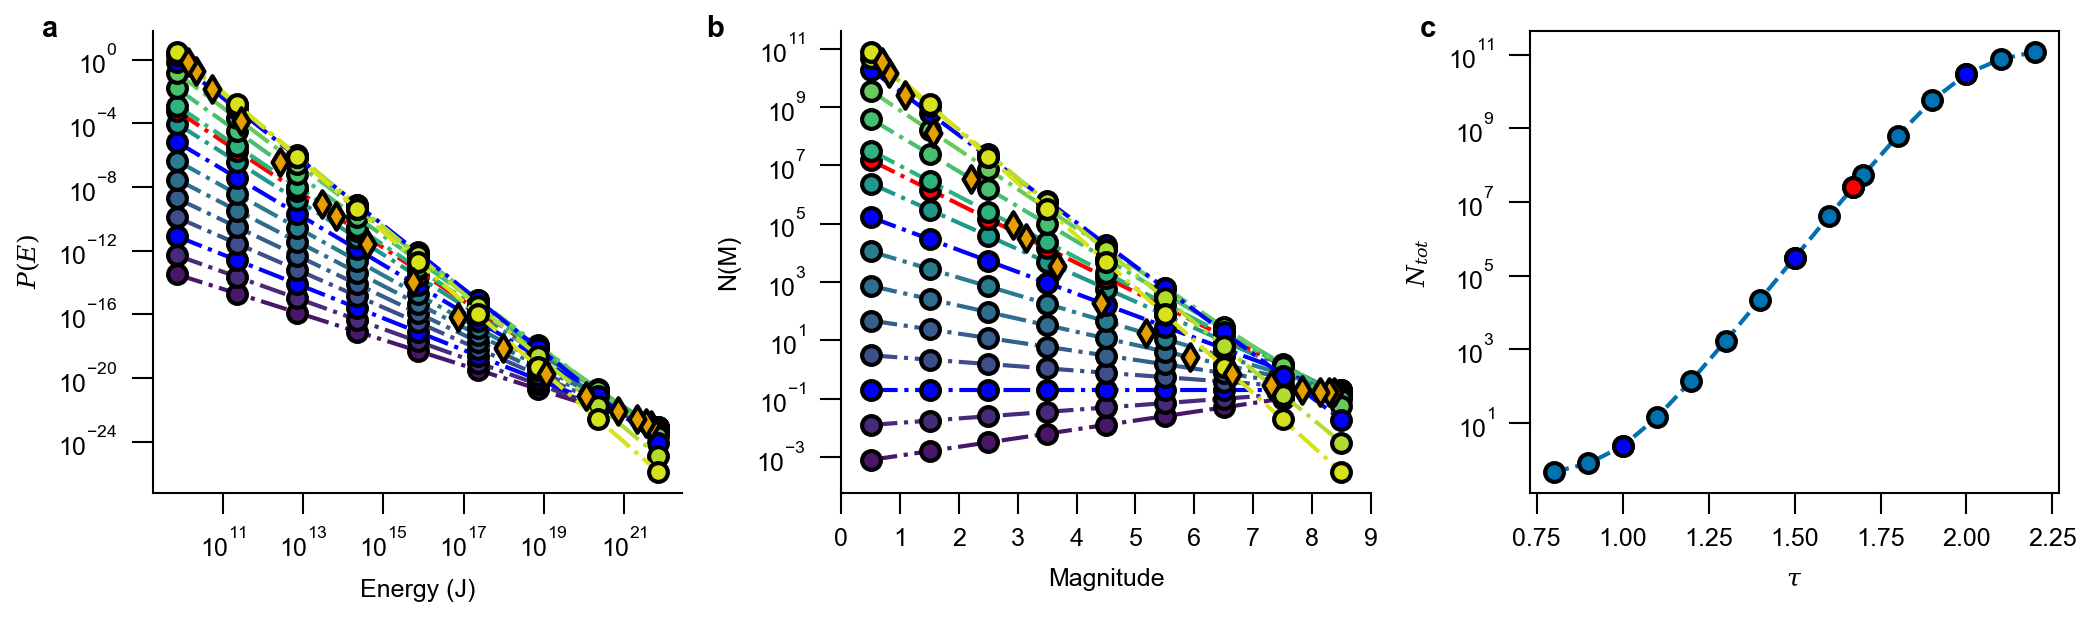

In [6]:

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    plt.rc('lines', markersize=4.5)
    
    fig, axs = plt.subplots(1,3, figsize = (8.2, 2))
    ax1 = axs[0]
    ax2 = axs[1]
    ax3 = axs[2]

    for n in range(1,ntot):
        if tau_values[n] in [1.0, 1.5,2.0000001]:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',label=f'tau={tau_values[n]:.2f}', c = 'b')
        elif tau_values[n] == 1.67:
            ax1.plot(E, P_E[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', label=f'tau={tau_values[n]:.2f}', c = 'r')
        else:
            ax1.plot(E, P_E[n], '-.o', c = colors[n], linewidth=1)
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',  c = colors[n], linewidth=1)
            
    ax1.scatter(mean_energy, mean_energy_y, marker = 'd', c = color_list[1], zorder = 10)  # point moyen
    ax2.scatter(mean_magnitude_x, mean_magnitude_y, marker = 'd', c = color_list[1], zorder = 10)

    ax3.plot(tau_values[1::1], Ntot[1::1], c = color_list[5], marker = 'o', ls = '--')
    mask = np.isin(tau_values, [1.0, 1.5, 2.0000001])
    ax3.scatter(tau_values[mask], Ntot[mask], c = 'b', marker = 'o', zorder = 2)
    ax3.scatter(tau_values[tau_values==1.67], Ntot[tau_values==1.67], c = 'r', marker = 'o', zorder = 2)


    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel(r'$P(E)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('N(M)')
    ax2.set_yscale('log')
    ax2.xaxis.set_ticks([0,1,2,3,4,5,6,7,8,9])

    ax3.set_xlabel(r'$\tau$')
    ax3.set_ylabel(r'$N_{tot}$')
    ax3.set_yscale('log')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)


    fig.text(0.08, 0.87, 'a', fontsize=7, fontweight="bold")
    fig.text(0.35, 0.87, 'b', fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.87, 'c', fontsize=7, fontweight="bold") 

    
    fig.subplots_adjust(hspace = 0.3, wspace = 0.3)
    
    fig.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax3.patch.set_alpha(0.0)
    fig.savefig('Fig3.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()


#   Figshare

##  Figure 2

In [16]:
japan_ratio = 23
cal_ratio = 43

labela = ["Mag_Jap","N_c_Jap", "xfit_Jap", "yfit_Jap", "Mag_Cal", "N_c_Cal", "xfit_Cal", "yfit_Cal"]
mask = N_sup_m_jap!=0
mask2 = N_sup_m_cal!=0
dfa = pd.DataFrame([distMAG_jap[:, 1][mask], N_sup_m_jap[mask], fitx_cdf_jap, fity_cdf_jap, distMAG_cal[:, 1][mask2], N_sup_m_cal[mask2], fitx_cdf_cal, fity_cdf_cal]).T

labelb = ["Mag_Jap","N_Jap", "xfit_Jap", "yfit_Jap", "Mag_Cal", "N_Cal", "xfit_Cal", "yfit_Cal"]

distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio
dfb = pd.DataFrame([distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio, fitx_mag_jap, fity_mag_jap, distMAG_cal[:, 1], distMAG_cal[:, 0] / cal_ratio, fitx_mag_cal, fity_mag_cal]).T

labelc = ["E_Jap","PDF_Jap", "xfit_Jap", "yfit_Jap", "E_Cal", "PDF_Cal", "xfit_Cal", "yfit_Cal"]
distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio
dfc = pd.DataFrame([distMAGMom_jap[:, 1], distMAGMom_jap[:, 0] / japan_ratio, fitx_jap, fity_jap, distMAGMom_cal[:, 1], distMAGMom_cal[:, 0] / cal_ratio, fitx_cal, fity_cal]).T

labeld = ["Date_Jap", "Cumulative Energy Release Japan (J)", "Date_Cal", "Cumulative Energy Release California (J)"]
dfd = pd.DataFrame([SMR1_jap[::10, 0], SMR1_jap[::10, 1], SMR1_cal[::10, 0], SMR1_cal[::10, 1]]).T

labele = ["Mag","N", "xfit", "yfit", "Extrapolation_x", "Extrapolation_y", "Mean_x", "Mean_y"]
dfe = pd.DataFrame([distMAG_jap[:, 1], distMAG_jap[:, 0] / japan_ratio, fitx_mag_jap, fity_mag_jap,magnitude_x, magnitude_y, [mean_magnitude_x], [mean_magnitude_y]]).T

labelf = ["Energy (J)","P(E)", "xfit", "yfit", "Extrapolation_x", "Extrapolation_y", "Mean_x", "Mean_y"]
dff = pd.DataFrame([distMAGMom_jap[:, 1], distMAGMom_jap[:, 0] / japan_ratio, fitx_jap, fity_jap, E, P_E, [mean_energy_x], [mean_energy_y]]).T

In [17]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_EQ/Data_excel/Figure2.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)
    dff.to_excel(writer, sheet_name="f", index=False)

##  Figure 3

In [8]:
labela = ["Energy(J)"]
[labela.extend(["P(E) (tau = {})".format(tau)]) for tau in tau_values[1:]]
labela.extend(["Mean_E", "Mean_P(E)"])
dfa = pd.DataFrame([E] + [P_E[n] for n in range(1, ntot)] + [mean_energy, mean_energy_y])
dfa = dfa.T
dfa.columns = labela


labelb = ["Magnitude"]
[labelb.extend(["N (tau = {})".format(tau)]) for tau in tau_values[1:]]
labelb.extend(["Mean_E", "Mean_P(E)"])
dfb = pd.DataFrame([magnitude_x] + [magnitude_y[n] for n in range(1, ntot)] + [mean_magnitude_x, mean_magnitude_y])
dfb = dfb.T
dfb.columns = labelb

labelc = ["tau", "<E>/<E_EQ>", "<M>"]
dfc = pd.DataFrame([tau_values[1:], mean_energy[1:]/mean_energy[tau_values==1.67], mean_magnitude_x[1:]]).T
dfc.columns = labelc

labeld = ["tau", "%E_M8", "%E_M0"]
dfd = pd.DataFrame([tau_values[1:], P_energy8[1:]*100, P_energy0[1:]*100]).T
dfd.columns = labeld

labele = ["tau", "T_M8"]
dfe = pd.DataFrame([tau_values[1:], 1/N8[1:]] ).T
dfe.columns = labele

labelf = ["b_1", "b"]
dff = pd.DataFrame([b1_values[1:], b_values[1:]] ).T
dff.columns = labelf

In [9]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_EQ/Data_excel/Figure3.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)
    dff.to_excel(writer, sheet_name="f", index=False)

#   Figure 4

In [9]:
labela = ["Energy(J)"]
[labela.extend(["P(E) (tau = {})".format(tau)]) for tau in tau_values[1:]]
labela.extend(["Mean_E", "Mean_P(E)"])
dfa = pd.DataFrame([E] + [P_E[n] for n in range(1, ntot)] + [mean_energy, mean_energy_y])
dfa = dfa.T
dfa.columns = labela


labelb = ["Magnitude"]
[labelb.extend(["N (tau = {})".format(tau)]) for tau in tau_values[1:]]
labelb.extend(["Mean_E", "Mean_P(E)"])
dfb = pd.DataFrame([magnitude_x] + [magnitude_y[n] for n in range(1, ntot)] + [mean_magnitude_x, mean_magnitude_y])
dfb = dfb.T
dfb.columns = labelb

labelc = ["tau", "Ntot"]
dfc = pd.DataFrame([tau_values[1:], Ntot[1:]]).T
dfc.columns = labelc

In [10]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_EQ/Data_excel/Figure4.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
